# Tải thư viện còn thiếu

In [1]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 69.8 MB/s eta 0:00:00


# Khai báo thư viện

In [2]:
import os
import numpy as np
import pandas as pd
from glob import glob
import rasterio
import matplotlib.pyplot as plt
from datetime import datetime
from functools import reduce

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from scipy.stats import pearsonr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Tiền xử lý dữ liệu

**Xử lý dữ liệu khí tượng ERA5**

In [3]:
def load_and_merge_meteo(base_path, variables):
    all_dfs = []
    for var in variables:
        print(f"Đang xử lý {var} :")
        records = []
        var_path = os.path.join(base_path, var)
        for year in ['2019', '2020']:
            for month in ['04', '10']:
                for day in [f"{d:02d}" for d in range(1, 32)]:
                    folder = os.path.join(var_path, year, month, day)
                    if not os.path.exists(folder): continue
                    for file in sorted(glob(os.path.join(folder, '*.tif'))):
                        try:
                            time_str = os.path.basename(file).split('_')[1].replace('.tif', '')
                            timestamp = pd.to_datetime(time_str, format='%Y%m%d%H%M%S')
                            with rasterio.open(file) as src:
                                val = np.nanmean(src.read(1))
                            records.append({'time': timestamp, var: val})
                        except:
                            continue
        df = pd.DataFrame(records)
        all_dfs.append(df)
    
    df_merged = reduce(lambda l, r: pd.merge(l, r, on='time', how='outer'), all_dfs)
    df_merged.dropna(inplace=True)
    df_merged.set_index('time', inplace=True)

    scaler = MinMaxScaler()
    df_merged[variables] = scaler.fit_transform(df_merged[variables])
    return df_merged

**Hàm Kalman Filter(tiền xử lý)**

In [4]:
from scipy.ndimage import gaussian_filter

def kalman_1d(z, Q=1e-5, R=1.0):
    x_hat = np.zeros(len(z))
    P = 1.0
    x_hat[0] = z[0]

    for k in range(1, len(z)):
        x_hat_minus = x_hat[k-1]
        P_minus = P + Q
        K = P_minus / (P_minus + R)
        x_hat[k] = x_hat_minus + K * (z[k] - x_hat_minus)
        P = (1 - K) * P_minus
    return x_hat

def kalman_2d(z, Q=1e-5, R=0.1):
    x_hat = np.zeros_like(z)
    P = np.ones_like(z)
    x_hat[0] = z[0]
    for k in range(1, z.shape[0]):
        # Prediction Step
        x_hat_minus = x_hat[k-1]
        P_minus = P[k-1] + Q
        
        # Update Step (Kết hợp Gaussian để làm mượt không gian)
        K = P_minus / (P_minus + R)
        x_hat[k] = x_hat_minus + K * (gaussian_filter(z[k], sigma=1) - x_hat_minus)
        P[k] = (1 - K) * P_minus
    return x_hat

def apply_kalman_to_radar(img):
    if img.ndim != 2:
        raise ValueError("Ảnh radar phải là 2D")
    # Áp dụng Kalman 2D theo chiều thời gian (giả sử img là ảnh đơn)
    smoothed = kalman_2d(img[np.newaxis, ...])[0]  # Giả định batch size=1
    return smoothed

**Xử lý dữ liệu Radar - Áp dụng Kalman Filter**
> Với data Radar đã được fill sẵn các vùng trắng bằng phương pháp Gaussian

In [ ]:
def load_radar_images(radar_root, apply_kalman=False):
    records = []
    for year in ['2019', '2020']:
        for month in ['04', '10']:
            for day in [f"{d:02d}" for d in range(1, 32)]:
                for hour in [f"{h:02d}" for h in range(24)]:
                    fname = f"Radar_{year}{month}{day}{hour}0000.tif"
                    fpath = os.path.join(radar_root, year, month, day, fname)
                    if not os.path.exists(fpath): continue

                    with rasterio.open(fpath) as src:
                        img = src.read(1).astype(np.float32)
                        img[img == src.nodata] = np.nan

                        if apply_kalman:
                            img = apply_kalman_to_radar(img)

                        records.append({
                            'datetime': datetime.strptime(f"{year}{month}{day}{hour}", "%Y%m%d%H"),
                            'image': np.nan_to_num(img)
                        })
    return sorted(records, key=lambda x: x['datetime'])

**Chia tập dữ liệu**
* 70% training set
* 15% validation set
* 15% test set

In [6]:
def split_records_by_time(radar_records, train_ratio=0.7, val_ratio=0.15):
    total_len = len(radar_records)
    train_end = int(train_ratio * total_len)
    val_end = int((train_ratio + val_ratio) * total_len)
    return radar_records[:train_end], radar_records[train_end:val_end], radar_records[val_end:]

# Tạo DATASET

In [7]:
class RadarWeatherDataset(Dataset):
    def __init__(self, radar_records, meteo_df, seq_len=6, forecast_horizon=1):
        self.radar = radar_records
        self.meteo = meteo_df
        self.seq_len = seq_len
        self.forecast_horizon = forecast_horizon

    def __len__(self):
        return len(self.radar) - self.seq_len - self.forecast_horizon

    def __getitem__(self, idx):
        radar_seq = []
        meteo_seq = []
        for i in range(self.seq_len):
            rec = self.radar[idx + i]
            radar_seq.append(rec['image'][np.newaxis, ...])
            t = rec['datetime']
            met = self.meteo.loc[t].values if t in self.meteo.index else np.zeros(self.meteo.shape[1])
            meteo_seq.append(met)

        radar_tensor = torch.tensor(np.stack(radar_seq), dtype=torch.float32)
        meteo_tensor = torch.tensor(np.stack(meteo_seq), dtype=torch.float32)

        target_img = self.radar[idx + self.seq_len + self.forecast_horizon - 1]['image']
        target_tensor = torch.tensor(target_img[np.newaxis, ...], dtype=torch.float32)

        return radar_tensor, meteo_tensor, target_tensor

# Xây dựng mô hình
**Sử dụng Unet kết hợp với Attention**

In [8]:
class AttentionBlock(nn.Module):
    """Attention block for U-Net"""
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        # g: từ encoder path (gates)
        # x: từ decoder path (inputs)
        
        # Check for size mismatch and fix if needed
        if g.size(2) != x.size(2) or g.size(3) != x.size(3):
            # Use the smaller dimensions
            target_h = min(g.size(2), x.size(2))
            target_w = min(g.size(3), x.size(3))
            
            # Crop both tensors to same size
            g = g[:, :, :target_h, :target_w]
            x = x[:, :, :target_h, :target_w]
            
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        
        # Make sure the attention mask matches the input size
        if psi.size(2) != x.size(2) or psi.size(3) != x.size(3):
            psi = F.interpolate(psi, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)
            
        return x * psi

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Dropout2d(0.2),  # Thêm spatial dropout
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
    
    def forward(self, x):
        return self.conv(x)


class EnhancedTemporalAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.channel_compress = nn.Conv3d(in_channels, 1, kernel_size=1)
        self.conv = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=(3,3,3), padding=1),
            nn.ReLU(),
            nn.Conv3d(8, 1, kernel_size=(3,3,3), padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        B, T, C, H, W = x.size()
        x_3d = x.permute(0, 2, 1, 3, 4)  # [B,C,T,H,W]
        compressed = self.channel_compress(x_3d)  # [B,1,T,H,W]
        attention = self.conv(compressed)
        return x * attention.permute(0,2,1,3,4).expand(-1,-1,C,-1,-1)
        

class UNetWithAttention(nn.Module):
    def __init__(self, input_channels=1, seq_len=6, features=[64, 128, 256, 512]):
        super(UNetWithAttention, self).__init__()
        self.seq_len = seq_len
        self.features = features  # Store features for later reference
        
        # Temporal attention for input sequence
        self.temporal_attention = EnhancedTemporalAttention(input_channels)
        
        # Sequence aggregation conv
        self.seq_aggregation = nn.Conv3d(input_channels, features[0], kernel_size=(seq_len, 3, 3), padding=(0, 1, 1))
        
        # Encoder blocks
        self.encoder1 = ConvBlock(features[0], features[0])
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.encoder2 = ConvBlock(features[0], features[1])
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.encoder3 = ConvBlock(features[1], features[2])
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bottleneck
        self.bottleneck = ConvBlock(features[2], features[3])
        
        # Decoder blocks with attention
        self.upconv3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.attention3 = AttentionBlock(F_g=features[2], F_l=features[2], F_int=features[1])
        self.decoder3 = ConvBlock(features[2] * 2, features[2])
        
        self.upconv2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.attention2 = AttentionBlock(F_g=features[1], F_l=features[1], F_int=features[0])
        self.decoder2 = ConvBlock(features[1] * 2, features[1])
        
        self.upconv1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.attention1 = AttentionBlock(F_g=features[0], F_l=features[0], F_int=max(1, features[0]//2))
        self.decoder1 = ConvBlock(features[0] * 2, features[0])
        
        # Weather parameter integration
        self.meteo_fc = nn.Sequential(
            nn.Linear(8, 64),  # Assuming 8 weather parameters
            nn.ReLU(),
            nn.Linear(64, features[3])  # Match to bottleneck size
        )

        self.meteo_proj = nn.ModuleDict({
            'bottleneck': nn.Sequential(
                nn.Linear(8, 512),
                nn.ReLU()
            ),
            'dec3': nn.Sequential(
                nn.Linear(8, 256),
                nn.ReLU()
            ),
            'dec2': nn.Sequential(
                nn.Linear(8, 128),
                nn.ReLU()
            )
        })
        
        # Output layer
        self.output_conv = nn.Conv2d(features[0], 1, kernel_size=1)
        
    def forward(self, x_radar, x_meteo=None):
        # x_radar: [B, T, C, H, W]
        # x_meteo: [B, T, M] (M là số đặc trưng khí tượng)
        
        B, T, C, H, W = x_radar.shape
        
        # Bước 1: Temporal Attention
        x_radar = self.temporal_attention(x_radar)
        
        # Bước 2: Aggregate sequence
        x = self.seq_aggregation(x_radar.permute(0, 2, 1, 3, 4))  # [B, C, T, H, W] -> [B, F0, 1, H, W]
        x = x.squeeze(2)  # [B, F0, H, W]
        
        # Bước 3: Encoder path
        e1 = self.encoder1(x)
        p1 = self.pool1(e1)
        
        e2 = self.encoder2(p1)
        p2 = self.pool2(e2)
        
        e3 = self.encoder3(p2)
        p3 = self.pool3(e3)
        
        # Bước 4: Bottleneck
        b = self.bottleneck(p3)
        
        # Bước 5: Tích hợp meteo vào bottleneck
        if x_meteo is not None:
            m = x_meteo.mean(dim=1)  # [B, M]
            b = b + self.meteo_proj['bottleneck'](m).view(B, -1, 1, 1)
        
        # Bước 6: Decoder path - Tầng 3
        d3 = self.upconv3(b)
        
        # Xử lý mismatch kích thước
        if d3.size()[2:] != e3.size()[2:]:
            d3 = F.interpolate(d3, size=e3.size()[2:], mode='bilinear', align_corners=False)
        
        # Attention và ghép features
        a3 = self.attention3(g=d3, x=e3)
        d3 = torch.cat((a3, d3), dim=1)
        d3 = self.decoder3(d3)
        
        # Tích hợp meteo vào decoder3
        if x_meteo is not None:
            m = x_meteo.mean(dim=1)
            d3 = d3 + self.meteo_proj['dec3'](m).view(B, -1, 1, 1)
        
        # Bước 7: Decoder path - Tầng 2
        d2 = self.upconv2(d3)
        
        if d2.size()[2:] != e2.size()[2:]:
            d2 = F.interpolate(d2, size=e2.size()[2:], mode='bilinear', align_corners=False)
        
        a2 = self.attention2(g=d2, x=e2)
        d2 = torch.cat((a2, d2), dim=1)
        d2 = self.decoder2(d2)
        
        # Tích hợp meteo vào decoder2
        if x_meteo is not None:
            m = x_meteo.mean(dim=1)
            d2 = d2 + self.meteo_proj['dec2'](m).view(B, -1, 1, 1)
        
        # Bước 8: Decoder path - Tầng 1
        d1 = self.upconv1(d2)
        
        if d1.size()[2:] != e1.size()[2:]:
            d1 = F.interpolate(d1, size=e1.size()[2:], mode='bilinear', align_corners=False)
        
        a1 = self.attention1(g=d1, x=e1)
        d1 = torch.cat((a1, d1), dim=1)
        d1 = self.decoder1(d1)
        
        # Bước 9: Output
        output = self.output_conv(d1)
        return output

# Huấn luyện và đánh giá mô hình

**Hàm Earlystopping để dùng sớm khi không có sự cải tiến thêm nào của mô hình**

In [9]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [10]:
class HybridLoss(nn.Module):
    def __init__(self, epsilon=1e-5):
        super().__init__()
        self.mse = nn.MSELoss()
        self.epsilon = epsilon
        
    def dice_loss(self, y_pred, y_true):
        y_pred = torch.sigmoid(y_pred)  # Đưa dự đoán về [0,1]
        intersect = (y_pred * y_true).sum()
        union = y_pred.sum() + y_true.sum()
        return 1 - (2 * intersect + self.epsilon) / (union + self.epsilon)
        
    def forward(self, y_pred, y_true):
        mse_loss = self.mse(y_pred, y_true)
        dice_loss = self.dice_loss(y_pred, (y_true > 0.1).float())
        return 0.7*mse_loss + 0.3*dice_loss

In [11]:
def create_weighted_sampler(dataset):
    # Lấy nhãn (0: không mưa, 1: có mưa)
    labels = []
    for i in range(len(dataset)):
        _, _, target = dataset[i]
        labels.append(torch.any(target > 0.1).item())  # Trả về bool
    
    # Tính toán class weights
    class_counts = np.bincount(labels)
    class_weights = 1. / torch.tensor(class_counts, dtype=torch.float32)
    
    # Tạo weights tensor đúng chuẩn PyTorch
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    sample_weights = class_weights[labels_tensor]  # Tensor 1D
    
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

In [12]:
def get_lr_scheduler(optimizer):
    return torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=1e-3, 
        steps_per_epoch=len(train_loader), 
        epochs=100
    )

In [13]:
def train_model_unet(model, train_loader, val_loader, epochs=50):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    loss_fn = HybridLoss()
    sampler = create_weighted_sampler(train_dataset)
    train_loader = DataLoader(
        dataset=train_dataset,  # Tên tham số rõ ràng
        batch_size=8,
        sampler=sampler,
        pin_memory=True,
        num_workers=2
    )

    # Thêm gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

     # Khởi tạo scheduler và early_stopping
    scheduler = get_lr_scheduler(optimizer)
    """ OR
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        patience=3, 
        factor=0.5
    )
    """
    early_stopping = EarlyStopping(patience=7)
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for x_radar, x_meteo, y_true in train_loader:
            x_radar, x_meteo, y_true = x_radar.to(device), x_meteo.to(device), y_true.to(device)
            
            optimizer.zero_grad()
            y_pred = model(x_radar, x_meteo)
            
            # Handle potential size mismatches between prediction and target
            if y_pred.size() != y_true.size():
                y_pred = F.interpolate(y_pred, size=(y_true.size(2), y_true.size(3)), 
                                      mode='bilinear', align_corners=False)
            
            loss = loss_fn(y_pred, y_true)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_radar, x_meteo, y_true in val_loader:
                x_radar, x_meteo, y_true = x_radar.to(device), x_meteo.to(device), y_true.to(device)
                y_pred = model(x_radar, x_meteo)
                
                # Handle potential size mismatches between prediction and target
                if y_pred.size() != y_true.size():
                    y_pred = F.interpolate(y_pred, size=(y_true.size(2), y_true.size(3)), 
                                          mode='bilinear', align_corners=False)
                
                val_losses.append(loss_fn(y_pred, y_true).item())

        mean_val_loss = np.mean(val_losses)
        print(f"[Epoch {epoch+1}] Train Loss: {np.mean(train_losses):.4f} | Val Loss: {mean_val_loss:.4f}")
        
        # Update learning rate based on validation loss
        scheduler.step(mean_val_loss)
        
        early_stopping(mean_val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break
    
    return model

**Hàm Kalman Filter(Hậu xử lý)**

In [14]:
def kalman_postprocess(pred_sequence, Q=1e-5, R=0.1):
    T, H, W = pred_sequence.shape
    smoothed = np.zeros_like(pred_sequence)
    
    # Thêm spatial smoothing
    kernel = np.ones((3,3))/9.
    
    for i in range(H):
        for j in range(W):
            # Lấy các pixel lân cận
            i_min = max(0, i-1)
            i_max = min(H, i+2)
            j_min = max(0, j-1)
            j_max = min(W, j+2)
            
            neighbor_series = pred_sequence[:, i_min:i_max, j_min:j_max].mean(axis=(1,2))
            smoothed[:,i,j] = kalman_1d(neighbor_series, Q, R)
    
    return smoothed

**Hàm đánh giá chung tổng thể model**

In [15]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x_radar, x_meteo, y_true in test_loader:
            x_radar, y_true = x_radar.to(device), y_true.to(device)
            y_pred = model(x_radar)
            all_preds.append(y_pred.cpu().numpy().flatten())
            all_targets.append(y_true.cpu().numpy().flatten())

    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    bias = np.mean(preds - targets)
    corr, _ = pearsonr(preds, targets)

    preds_bin = preds > 0.1
    targets_bin = targets > 0.1
    tn, fp, fn, tp = confusion_matrix(targets_bin, preds_bin, labels=[0,1]).ravel()
    csi = tp / (tp + fn + fp)

    print(f"📈 RMSE: {rmse:.4f}")
    print(f"📉 Bias: {bias:.4f}")
    print(f"🔗 Pearson R: {corr:.4f}")
    print(f"🌧️ CSI: {csi:.4f}")

**Hàm đánh giá cho các dự đoán**

In [16]:
def evaluate_forecast(preds, targets):
    for t in range(preds.shape[0]):
        pred = preds[t].flatten()
        target = targets[t].flatten()

        rmse = np.sqrt(np.mean((pred - target) ** 2))
        bias = np.mean(pred - target)
        corr, _ = pearsonr(pred, target)

        preds_bin = pred > 0.1
        targets_bin = target > 0.1
        tn, fp, fn, tp = confusion_matrix(targets_bin, preds_bin, labels=[0,1]).ravel()
        csi = tp / (tp + fn + fp)

        print(f"[{t+1}h] 📈 RMSE: {rmse:.4f} | 📉 Bias: {bias:.4f} | 🔗 Corr: {corr:.4f} | 🌧️ CSI: {csi:.4f}")

**Hàm dự đoán cho mô hình**

In [17]:
def predict_sliding_unet(model, dataset, idx=100, forecast_steps=6, apply_kalman=False):
    # Add import for torch.nn.functional
    import torch.nn.functional as F
    
    model.eval()
    x_radar, x_meteo, y_true = dataset[idx]
    x_radar = x_radar.unsqueeze(0).to(device)  # [1, seq_len, 1, H, W]
    x_meteo = x_meteo.unsqueeze(0).to(device)  # [1, seq_len, M]
    target_size = y_true.shape[-2:]  # Get target size (H, W)

    preds = []
    for step in range(forecast_steps):
        y_pred = model(x_radar, x_meteo)
        
        # Ensure prediction matches target size
        if y_pred.shape[-2:] != target_size:
            y_pred = F.interpolate(y_pred, size=target_size, mode='bilinear', align_corners=False)
            
        preds.append(y_pred.squeeze(0).detach().cpu().numpy())

    preds = np.stack(preds)  # [T, 1, H, W]
    preds = preds[:, 0, :, :]  # remove channel dim

    if apply_kalman:
        preds = kalman_postprocess(preds)

    return preds

In [18]:
def predict_autoregressive_unet(model, dataset, idx=100, forecast_steps=6, apply_kalman=True):
    model.eval()
    x_radar, x_meteo, y_true = dataset[idx]
    x_radar = x_radar.clone().unsqueeze(0).to(device)  # [1, seq_len, 1, H, W]
    x_meteo = x_meteo.clone().unsqueeze(0).to(device)  # [1, seq_len, M]

    preds = []
    for step in range(forecast_steps):
        y_pred = model(x_radar, x_meteo)
        preds.append(y_pred.squeeze(0).detach().cpu().numpy())

        # Update: bỏ frame cũ nhất + ghép thêm frame mới nhất
        new_frame = y_pred.unsqueeze(1)  # [1,1,H,W]
        x_radar = torch.cat([x_radar[:, 1:], new_frame], dim=1)  # slide window
        
        # For meteo data, we just keep using the same sequence since we don't have future values
        # In a real application, you might want to forecast meteo data as well

    preds = np.stack(preds)  # [T, 1, H, W]
    preds = preds[:, 0, :, :]

    if apply_kalman:
        preds = kalman_postprocess(preds)

    return preds

# Đưa ra hình ảnh dự đoán

In [19]:
def visualize_forecast(preds, targets):
    T = preds.shape[0]
    plt.figure(figsize=(15, 5 * T))
    for t in range(T):
        plt.subplot(T, 2, 2*t+1)
        plt.imshow(targets[t], cmap='jet')
        plt.title(f"Ground Truth {t+1}h")
        plt.colorbar()

        plt.subplot(T, 2, 2*t+2)
        plt.imshow(preds[t], cmap='jet')
        plt.title(f"Prediction {t+1}h")
        plt.colorbar()

    plt.tight_layout()
    plt.show()

# Chạy toàn bộ quy trình

In [20]:
variables = ["CAPE", "U250", "R250", "TCWV", "TCLW", "TCW", "V850", "U850"]

radar_records = load_radar_images('/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar')
meteo_df = load_and_merge_meteo('/kaggle/input/data-rain-ai/DATA_SV/ERA5', variables)


Đang xử lý CAPE :
Đang xử lý U250 :
Đang xử lý R250 :
Đang xử lý TCWV :
Đang xử lý TCLW :
Đang xử lý TCW :
Đang xử lý V850 :
Đang xử lý U850 :


In [21]:
radar_train, radar_val, radar_test = split_records_by_time(radar_records)

train_dataset = RadarWeatherDataset(radar_train, meteo_df)
val_dataset = RadarWeatherDataset(radar_val, meteo_df)
test_dataset = RadarWeatherDataset(radar_test, meteo_df)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)
test_loader = DataLoader(test_dataset, batch_size=1)

In [22]:
# Create the model
model = UNetWithAttention(
    input_channels=1,
    seq_len=6,
    features=[64, 128, 256, 512]  # Tăng capacity
).to(device)

if torch.cuda.device_count() > 1:
    print(f"🔥 Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# Train the model
train_model_unet(model, train_loader, val_loader)

🔥 Using 2 GPUs!
[Epoch 1] Train Loss: 0.7449 | Val Loss: 1.4022


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


[Epoch 2] Train Loss: 0.9905 | Val Loss: 1.2412
[Epoch 3] Train Loss: 1.0816 | Val Loss: 1.2489
[Epoch 4] Train Loss: 0.9333 | Val Loss: 1.1288
[Epoch 5] Train Loss: 1.0050 | Val Loss: 1.4788
[Epoch 6] Train Loss: 0.9184 | Val Loss: 1.3056
[Epoch 7] Train Loss: 1.0074 | Val Loss: 1.3683
[Epoch 8] Train Loss: 0.9705 | Val Loss: 1.2598
[Epoch 9] Train Loss: 0.8532 | Val Loss: 1.3362
[Epoch 10] Train Loss: 0.7782 | Val Loss: 1.4668
[Epoch 11] Train Loss: 1.3657 | Val Loss: 1.2867
Early stopping triggered.


DataParallel(
  (module): UNetWithAttention(
    (temporal_attention): EnhancedTemporalAttention(
      (channel_compress): Conv3d(1, 1, kernel_size=(1, 1, 1), stride=(1, 1, 1))
      (conv): Sequential(
        (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): ReLU()
        (2): Conv3d(8, 1, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (3): Sigmoid()
      )
    )
    (seq_aggregation): Conv3d(1, 64, kernel_size=(6, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1))
    (encoder1): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout2d(p=0.2, inplace=False)
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        

In [23]:
# Evaluate the model
evaluate_model(model, test_loader)

# Dự báo liên tiếp 6 giờ kiểu Sliding
preds_sliding = predict_sliding_unet(model, test_dataset, idx=40, forecast_steps=6, apply_kalman=True)

# Ground Truth 6 giờ tới
_, _, target_img = test_dataset[40]
target6_seq = []
for i in range(6):
    _, _, img = test_dataset[40+i]
    target6_seq.append(img.squeeze(0).numpy())
target6_seq = np.stack(target6_seq)

# Đánh giá
print("🎯 Đánh giá dự báo kiểu Sliding:")
evaluate_forecast(preds_sliding, target6_seq)

📈 RMSE: 2.2475
📉 Bias: -0.2036
🔗 Pearson R: 0.4959
🌧️ CSI: 0.4931
🎯 Đánh giá dự báo kiểu Sliding:
[1h] 📈 RMSE: 1.6255 | 📉 Bias: -0.3300 | 🔗 Corr: 0.7619 | 🌧️ CSI: 0.6559
[2h] 📈 RMSE: 1.8334 | 📉 Bias: -0.2972 | 🔗 Corr: 0.5780 | 🌧️ CSI: 0.6387
[3h] 📈 RMSE: 1.6865 | 📉 Bias: -0.2800 | 🔗 Corr: 0.4284 | 🌧️ CSI: 0.6222
[4h] 📈 RMSE: 0.8724 | 📉 Bias: 0.0047 | 🔗 Corr: 0.4777 | 🌧️ CSI: 0.4966
[5h] 📈 RMSE: 1.4536 | 📉 Bias: -0.1967 | 🔗 Corr: 0.3859 | 🌧️ CSI: 0.4666
[6h] 📈 RMSE: 1.3795 | 📉 Bias: -0.1896 | 🔗 Corr: 0.4239 | 🌧️ CSI: 0.3919


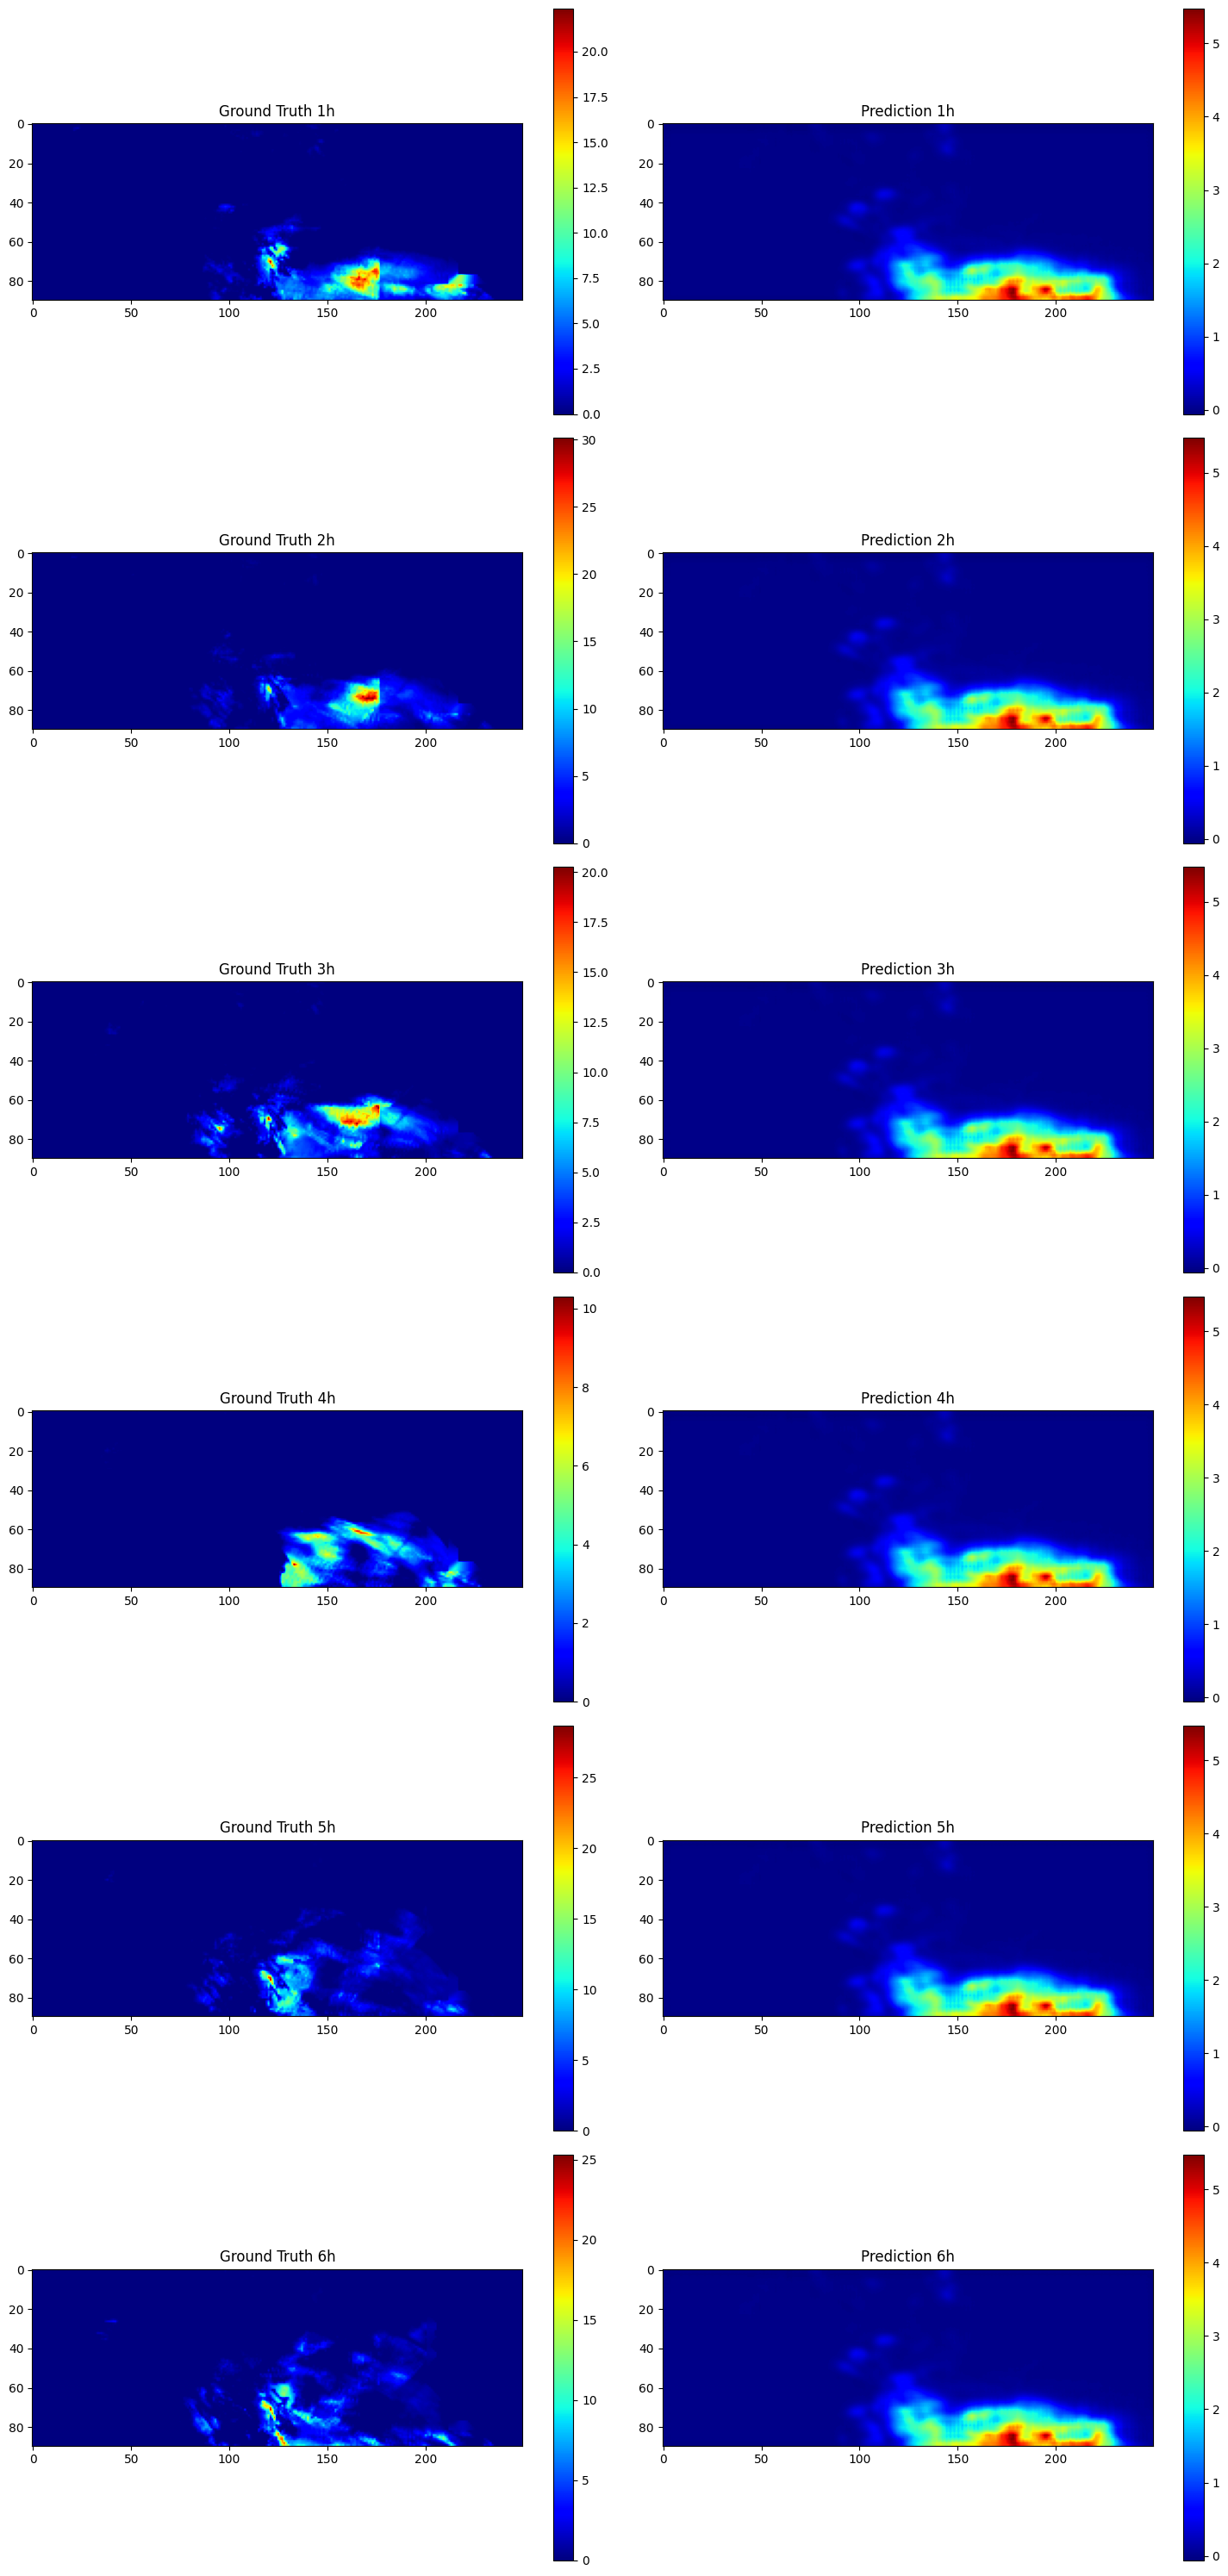

In [24]:
# Hiển thị
visualize_forecast(preds_sliding, target6_seq)